In [1]:
import fuse
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

2025-12-08 11:59:34,734 - utilix - WARNING - Could not load a configuration file. You can create one at /home/l-althueser/.xenon_config, or set a custom path using

export XENON_CONFIG=path/to/your/config



In [12]:
st = fuse.context.public_config_context(output_folder="./fuse_data", 
                                        simulation_config_file="./fuse_files/XENONnT_public_config.json",
                                        clustering_method="lineage")

st.set_config(
    {
        "path": "../",
        "file_name": "20251205_Sapphire_U238_neutron_100k.root",
        "entry_stop": 200,
    }
)

run_number = "00000"

In [13]:
st.make(run_number, "geant4_interactions")
#st.make(run_number, "cluster_index")
st.make(run_number, "interaction_lineage")

geant4_interactions = st.get_df(run_number, ["geant4_interactions", "interaction_lineage"])

INFO:ChunkInput:Using random event times.
INFO:ChunkInput:Simulating data in 7 chunks.


ChunkInput with object id: 133015576487792 waits for chunk 1
ChunkInput with object id: 133015576487792 waits for chunk 2
ChunkInput with object id: 133015576487792 waits for chunk 3
ChunkInput with object id: 133015576487792 waits for chunk 4
ChunkInput with object id: 133015576487792 waits for chunk 5
ChunkInput with object id: 133015576487792 waits for chunk 6
Source finished!


In [14]:
geant4_interactions.head(10)

,x,y,z,t,ed,type,trackid,parenttype,parentid,creaproc,...,z_pri,time,endtime,lineage_index,event_lineage_index,lineage_trackid,lineage_type,A,Z,main_cluster_type
0,-25.689053,23.495047,37.854073,0.000000,0.000000,neutron,1,none,0,Null,...,29.278896,1282971275,1282971275,1,1,1,0,0,0,None
1,-25.689053,23.495047,37.854073,0.000002,12.349370,Xe132,2,neutron,1,hadElastic,...,29.278896,1282971275,1282971275,4,4,2,0,0,0,alpha
2,-25.689053,23.495047,37.854073,0.000002,0.000000,Xe132,2,neutron,1,hadElastic,...,29.278896,1282971275,1282971275,5,5,2,0,0,0,None
3,-13.321859,34.732811,45.850288,10.193614,0.000000,neutron,1,none,0,Null,...,29.278896,1282971285,1282971285,2,2,1,0,0,0,None
4,44.922066,87.657616,83.508881,58.200951,0.000000,neutron,1,none,0,Null,...,29.278896,1282971333,1282971333,3,3,1,0,0,0,None
5,44.922066,87.657616,83.508881,58.200951,10.742385,Xe131,6,neutron,1,neutronInelastic,...,29.278896,1282971333,1282971333,12,12,6,0,0,0,alpha
6,44.922066,87.657616,83.508881,58.200951,0.000000,Xe131,6,neutron,1,neutronInelastic,...,29.278896,1282971333,1282971333,13,13,6,0,0,0,None
7,44.921844,87.656662,83.361320,58.205875,0.336650,gamma,5,neutron,1,neutronInelastic,...,29.278896,1282971333,1282971333,11,11,5,8,0,0,None
8,44.921844,87.656662,83.361320,58.205875,0.020560,e-,26,gamma,5,phot,...,29.278896,1282971333,1282971333,11,11,5,8,0,0,None
9,44.921844,87.656662,83.361320,58.205875,0.045140,e-,25,gamma,5,phot,...,29.278896,1282971333,1282971333,11,11,5,8,0,0,None


In [15]:
st.show_config("clustered_interactions")

,option,default,current,applies_to,help
0,debug,False,<OMITTED>,"(clustered_interactions,)",Show debug informations
1,deterministic_seed,True,<OMITTED>,"(clustered_interactions,)","Set the random seed from lineage and run_id, o..."
2,user_defined_random_seed,None,<OMITTED>,"(clustered_interactions,)",Define the random seed manually. You need to s...
3,debug,False,<OMITTED>,"(interaction_lineage,)",Show debug informations
4,deterministic_seed,True,<OMITTED>,"(interaction_lineage,)","Set the random seed from lineage and run_id, o..."
5,user_defined_random_seed,None,<OMITTED>,"(interaction_lineage,)",Define the random seed manually. You need to s...
6,gamma_distance_threshold,0.0,<OMITTED>,"(interaction_lineage,)",Distance threshold to break lineage for gamma ...
7,brem_distance_threshold,0,<OMITTED>,"(interaction_lineage,)",Distance threshold to break lineage for bremss...
8,time_threshold,10,<OMITTED>,"(interaction_lineage,)",Time threshold to break the lineage [ns]
9,classify_ic_as_gamma,True,<OMITTED>,"(interaction_lineage,)",Classify internal conversion electrons as gamm...


In [16]:
st.make(run_number, "clustered_interactions")

geant4_clusters = st.get_df(run_number, ["clustered_interactions"])

Loading ['clustered_interactions']: |          | 0.00 % [00:00<?]

In [17]:
geant4_clusters.head(10)

,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime
0,-25.689053,23.495047,37.854073,12.349370,0,4,0,2,0.000002,0,0,-28.23917,24.456776,29.278896,1282971275,1282971275
1,44.090919,88.128105,83.541283,63.618973,8,41,0,3694,58.235291,0,0,-28.23917,24.456776,29.278896,1282971332,1282971332
2,44.676823,87.736702,83.403938,490.132721,8,6,0,3,58.213382,0,0,-28.23917,24.456776,29.278896,1282971332,1282971332
3,44.929089,87.663918,83.368057,88.360580,8,11,0,5,58.206368,0,0,-28.23917,24.456776,29.278896,1282971332,1282971332
4,44.080788,88.118500,83.547424,764.926819,8,7,0,3,58.237378,0,0,-28.23917,24.456776,29.278896,1282971333,1282971333
5,44.092781,88.128044,83.543350,3.646556,8,42,0,3700,58.235100,0,0,-28.23917,24.456776,29.278896,1282971333,1282971333
6,44.682198,87.740379,83.418861,30.605997,8,43,0,4177,58.214161,0,0,-28.23917,24.456776,29.278896,1282971333,1282971333
7,44.922066,87.657616,83.508881,10.742385,0,12,0,6,58.200951,0,0,-28.23917,24.456776,29.278896,1282971333,1282971333
8,44.184689,89.406342,84.943756,1.216672,0,14,0,92,61.967865,0,0,-28.23917,24.456776,29.278896,1282971336,1282971336
9,51.084213,86.753654,81.860001,107.998734,8,16,0,94,78.734341,0,0,-28.23917,24.456776,29.278896,1282971353,1282971353


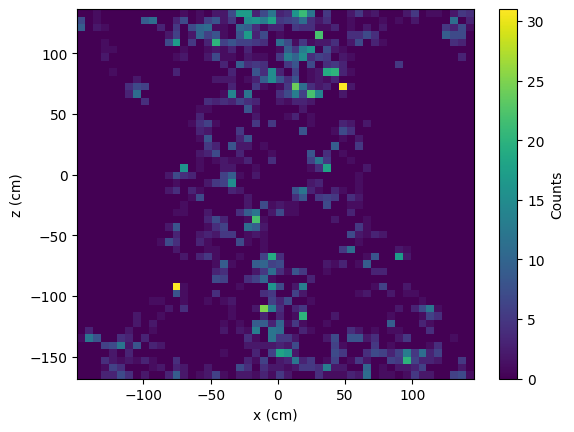

In [21]:
# 2d histogram of cluster positions in xz plane
plt.hist2d(geant4_clusters["x"], geant4_clusters["z"], bins=50)
plt.xlabel("x (cm)")
plt.ylabel("z (cm)")
plt.colorbar(label="Counts")
plt.show()

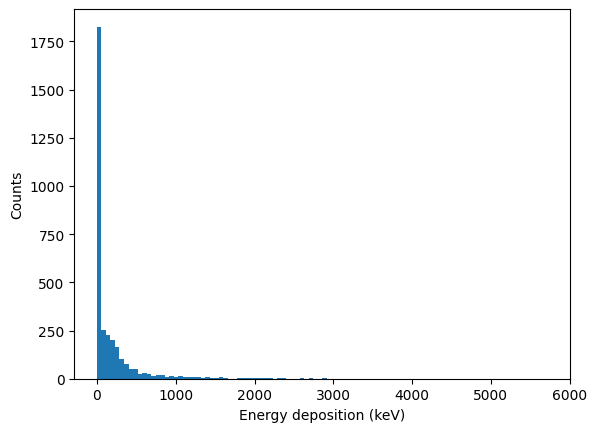

In [20]:
plt.hist(geant4_clusters["ed"], bins=100)
plt.xlabel("Energy deposition (keV)")
plt.ylabel("Counts")

plt.show()